# OpenAI Model Comparison for Phishing Detection

Comparing the performance of:

1. GPT-4o-mini with original prompt
2. GPT-4o-mini with enhanced prompt
3. Fine-tuned GPT-4o-mini

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os
from openai import OpenAI
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import dotenv

# Load environment variables
dotenv.load_dotenv()

True

In [2]:
## 1. Load the Test Dataset

data = pd.read_csv('test_dataset.csv')

# Basic preprocessing
data = data.dropna()
data = data.drop_duplicates()
data = data.reset_index(drop=True)

# Create combined text field
data['text_combined'] = "SENDER: " + data['sender'] + " SUBJECT: " + data['subject'] + " BODY: " + data['body']

# Display sample
print("Test dataset shape:", data.shape)
data.head()

Test dataset shape: (8503, 6)


,sender,subject,body,label,source,text_combined
0,ohwwlejs-pbfotbp@list.scms.waikato.ac.nz,"Wekalist Digest, Vol 60, Issue 11",Send Wekalist mailing list submissions to \tiu...,0,CEAS_08,SENDER: ohwwlejs-pbfotbp@list.scms.waikato.ac....
1,under@hmo.megared.net.mx,A small thing to make your woman happy.,In Canadian Chemist we trust. http://urx.medic...,1,CEAS_08,SENDER: under@hmo.megared.net.mx SUBJECT: A sm...
2,Isabelle Bichindaritz <kaupuiws@u.washington.edu>,[UAI] CFP CBR in the Health Sciences Workshop ...,\n\n Workshop on CBR in the H...,0,CEAS_08,SENDER: Isabelle Bichindaritz <kaupuiws@u.wash...
3,"""Elsy Moriarty"" <pekerhead@postino.ch>",Refinance or MortgageFKZQELJHYNO,<= FONT color=3D#66ccff size=3D5>What a Loan F...,1,SpamAssasin,"SENDER: ""Elsy Moriarty"" <pekerhead@postino.ch>..."
4,Alissa Gallagher <ahynrqk@boegerwinery.com>,123,I got good news for you! That is a superb perf...,1,CEAS_08,SENDER: Alissa Gallagher <ahynrqk@boegerwinery...


In [ ]:
## 2. OpenAI Model Setup

# Initialize OpenAI client
client = OpenAI(
    api_key=os.getenv('OPENAI_API_KEY'),
    organization=os.getenv('OPENAI_ORG_ID')
)

def predict_with_openai_original(text, max_retries=3):
    """Original prompt version"""
    system_prompt = """You are a cybersecurity expert specializing in phishing email detection. 
    Analyze the provided email and determine if it's a phishing attempt. 
    Consider urgency tactics, suspicious links, grammatical errors, too-good-to-be-true offers, and other markers. 
    You must respond with ONLY the word 'yes' if it's phishing or 'no' if it's legitimate.
    Do not include any other text, explanation, or punctuation in your response."""
    
    attempts = 0
    while attempts < max_retries:
        try:
            # Add small delay between requests
            time.sleep(1)
            
            response = client.chat.completions.create(
                model=os.getenv('OPENAI_MODEL_NAME', 'gpt-4o-mini'),
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": text}
                ],
                temperature=0.3,
                max_tokens=10
            )
            
            prediction = response.choices[0].message.content.strip().lower()
            
            if prediction in ["yes", "no"]:
                return prediction == "yes"
            
            attempts += 1
            
        except Exception as e:
            print(f"Error: {str(e)}")
            attempts += 1
            time.sleep(2)
    
    raise Exception(f"Failed to get valid response after {max_retries} attempts")

def predict_with_openai_enhanced(text, max_retries=3):
    """Enhanced prompt version"""
    system_prompt = """Determine if the email content suggests a potential phishing threat with a simple "yes" or "no" response.

    # Steps

    1. **Identify Red Flags**: 
    - Look for suspicious language, such as urgent requests for personal information, unverifiable sender details, or unexpected attachments.
    - Check for poor grammar, spelling mistakes, or awkward phrasing.

    2. **Evaluate Context**: 
    - Consider if the email requests sensitive information or actions that are unusual, like changing login credentials.
    - Assess the legitimacy of provided links or email addresses by looking for slight misspellings of trusted domains.

    3. **Analyze Tone and Format**: 
    - Note if the email uses aggressive or alarming language intended to prompt immediate action.
    - Evaluate the overall tone to see if it mimics trusted entities or uses titles improperly.

    # Output Format

    - Provide a single word response: "yes" if the email seems like a phishing attempt, otherwise "no".

    # Examples

    **Example 1:**

    - **Input**: "Congrats! You've won a prize! Click www.fakeurl123.com to claim now!"
    - **Reasoning**: The email promises a prize with a suspicious URL and urgency to click a link.
    - **Output**: "yes"

    **Example 2:**

    - **Input**: "Hello, can we reschedule our meeting to next week?"
    - **Reasoning**: The email content is a simple request with no suspicious elements.
    - **Output**: "no"

    # Notes

    - Be cautious of emails mimicking reputable organizations but having minor errors in logo, email address, or message structure.
    - Contextual understanding and evaluating subtle cues play a key role in distinguishing phishing attempts from legitimate emails."""
    
    attempts = 0
    while attempts < max_retries:
        try:
            # Add small delay between requests
            time.sleep(1)
            
            response = client.chat.completions.create(
                model=os.getenv('OPENAI_MODEL_NAME', 'gpt-4o-mini'),
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": text}
                ],
                temperature=0.3,
                max_tokens=10
            )
            
            prediction = response.choices[0].message.content.strip().lower()
            
            if prediction in ["yes", "no"]:
                return prediction == "yes"
            
            attempts += 1
            
        except Exception as e:
            print(f"Error: {str(e)}")
            attempts += 1
            time.sleep(2)
    
    raise Exception(f"Failed to get valid response after {max_retries} attempts")

def predict_with_openai_finetuned(text, max_retries=3):
    """Fine-tuned model version"""
    system_prompt = """You are a cybersecurity expert specializing in phishing email detection. 
    Analyze the provided email and determine if it's a phishing attempt. 
    Consider urgency tactics, suspicious links, grammatical errors, too-good-to-be-true offers, and other markers. 
    You must respond with ONLY the word 'yes' if it's phishing or 'no' if it's legitimate.
    Do not include any other text, explanation, or punctuation in your response."""
    attempts = 0
    while attempts < max_retries:
        try:
            # Add small delay between requests
            time.sleep(1)
            
            response = client.chat.completions.create(
                model=os.getenv('OPENAI_FINETUNED_MODEL_NAME'),
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": text}
                ],
                temperature=0.3,
                max_tokens=10
            )
            
            prediction = response.choices[0].message.content.strip().lower()
            
            if prediction in ["yes", "no"]:
                return prediction == "yes"
            
            attempts += 1
            
        except Exception as e:
            print(f"Error: {str(e)}")
            attempts += 1
            time.sleep(2)
    
    raise Exception(f"Failed to get valid response after {max_retries} attempts")

In [4]:
## 3. Evaluation Functions

def evaluate_model(texts, predict_fn, sample_size=100):
    """Evaluate a model on a sample of texts"""
    # Sample texts to avoid excessive API calls
    if len(texts) > sample_size:
        sampled_indices = np.random.choice(len(texts), sample_size, replace=False)
        texts = texts[sampled_indices]
    
    predictions = []
    for text in tqdm(texts, desc="Processing with OpenAI"):
        try:
            pred = predict_fn(text)
            predictions.append(pred)
        except Exception as e:
            print(f"Error processing text: {str(e)}")
            predictions.append(None)
    
    return predictions

In [6]:
## 4. Model Comparison

# Set sample size for evaluation
sample_size = len(data)  # Adjust based on API limits and budget

# Sample data
sampled_indices = np.random.choice(len(data), sample_size, replace=False)
sampled_data = data.iloc[sampled_indices]

# Evaluate original prompt model
print("\nEvaluating Original Prompt Model...")
original_predictions = evaluate_model(sampled_data['text_combined'], predict_with_openai_original, sample_size=sample_size)

# Remove any None values from failed predictions
valid_indices = [i for i, pred in enumerate(original_predictions) if pred is not None]
original_predictions = [original_predictions[i] for i in valid_indices]
original_true_labels = sampled_data['label'].iloc[valid_indices]

print("\nOriginal Prompt Model Performance:")
print(classification_report(original_true_labels, original_predictions))

# Create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(original_true_labels, original_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Original Prompt Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


Evaluating Original Prompt Model...


Processing with OpenAI:   1%|          | 73/8503 [01:46<3:25:25,  1.46s/it]


KeyboardInterrupt: 

In [ ]:
# Evaluate enhanced prompt model
print("\nEvaluating Enhanced Prompt Model...")
enhanced_predictions = evaluate_model(sampled_data['text_combined'], predict_with_openai_enhanced, sample_size=sample_size)

# Remove any None values from failed predictions
valid_indices = [i for i, pred in enumerate(enhanced_predictions) if pred is not None]
enhanced_predictions = [enhanced_predictions[i] for i in valid_indices]
enhanced_true_labels = sampled_data['label'].iloc[valid_indices]

print("\nEnhanced Prompt Model Performance:")
print(classification_report(enhanced_true_labels, enhanced_predictions))

# Create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(enhanced_true_labels, enhanced_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Enhanced Prompt Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


Evaluating Fine-tuned Model...


Processing with OpenAI:  25%|██▌       | 2161/8503 [54:10<2:31:13,  1.43s/it]

Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150329 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150329 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}
Error: Error code: 400 - {'error': {'message': "This model's maximum context length is 128000 tokens. However, your messages resulted in 150329 tokens. Please reduce the length of the messages.", 'type': 'invalid_request_error', 'param': 'messages', 'code': 'context_length_exceeded'}}


Processing with OpenAI:  25%|██▌       | 2162/8503 [54:21<7:19:14,  4.16s/it]

Error processing text: Failed to get valid response after 3 attempts


Processing with OpenAI: 100%|██████████| 8503/8503 [3:29:44<00:00,  1.48s/it]  


Fine-tuned Model Performance:
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      4279
           1       0.90      1.00      0.95      4223

    accuracy                           0.94      8502
   macro avg       0.95      0.94      0.94      8502
weighted avg       0.95      0.94      0.94      8502



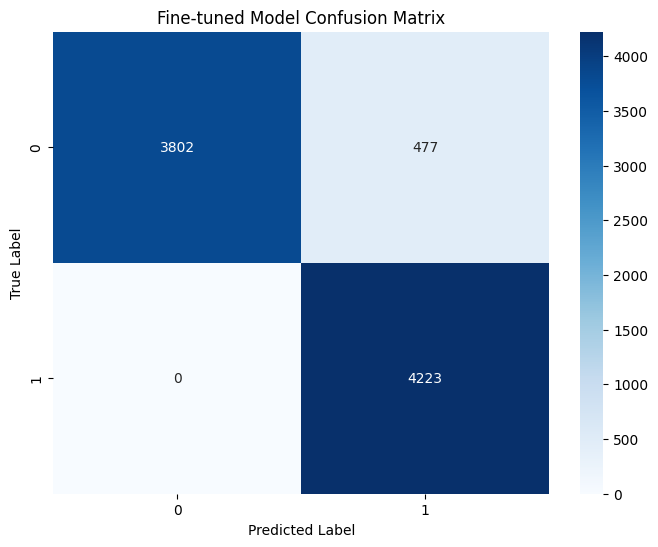

In [7]:
# Evaluate fine-tuned model
print("\nEvaluating Fine-tuned Model...")
finetuned_predictions = evaluate_model(sampled_data['text_combined'], predict_with_openai_finetuned, sample_size=sample_size)

# Remove any None values from failed predictions
valid_indices = [i for i, pred in enumerate(finetuned_predictions) if pred is not None]
finetuned_predictions = [finetuned_predictions[i] for i in valid_indices]
finetuned_true_labels = sampled_data['label'].iloc[valid_indices]

print("\nFine-tuned Model Performance:")
print(classification_report(finetuned_true_labels, finetuned_predictions))

# Create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(finetuned_true_labels, finetuned_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Fine-tuned Model Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
## 5. Error Analysis

def analyze_errors(texts, true_labels, predictions, model_name):
    """Analyze misclassified examples"""
    errors = []
    for text, true_label, pred in zip(texts, true_labels, predictions):
        if true_label != pred:
            errors.append({
                'text': text,
                'true_label': true_label,
                'predicted': pred
            })
    
    print(f"\n{model_name} Error Analysis")
    print(f"Total errors: {len(errors)}")
    print(f"Error rate: {len(errors)/len(true_labels):.2%}")
    
    # Display a few example errors
    print("\nExample misclassifications:")
    for i, error in enumerate(errors[:3]):
        print(f"\nError {i+1}:")
        print(f"True label: {'Phishing' if error['true_label'] else 'Legitimate'}")
        print(f"Predicted: {'Phishing' if error['predicted'] else 'Legitimate'}")
        print(f"Text snippet: {error['text'][:200]}...")

# Analyze errors for all models
print("\nOriginal Prompt Model Errors:")
analyze_errors(
    sampled_data['text_combined'].iloc[valid_indices],
    original_true_labels,
    original_predictions,
    "Original Prompt Model"
)

print("\nEnhanced Prompt Model Errors:")
analyze_errors(
    sampled_data['text_combined'].iloc[valid_indices],
    enhanced_true_labels,
    enhanced_predictions,
    "Enhanced Prompt Model"
)

print("\nFine-tuned Model Errors:")
analyze_errors(
    sampled_data['text_combined'].iloc[valid_indices],
    finetuned_true_labels,
    finetuned_predictions,
    "Fine-tuned Model"
)